# So sánh 4 phương pháp Knowledge Distillation cho Image Captioning thời trang

**Teacher (dùng chung, huấn luyện 1 lần):** BLIP-large — vision encoder đóng băng, fine-tune decoder.
**Student (4 biến thể, kiến trúc giống hệt nhau):** BLIP-base, đã **prune decoder** (giữ so le layer
`0, 3, 6, 9`), sinh caption với `num_beams=1` + `use_cache=True` (KV-cache mặc định) để tối ưu tốc độ
suy luận thực tế.

Cả 4 phương pháp dùng **chung** loss: `loss = loss_gt (CE) + λ_resp · Word-KD (response) + λ_feat · Feature-KD`.
Chỉ **phần Feature-KD** khác nhau:

| Phương pháp | Feature-KD dùng |
|---|---|
| 1 | **FitNets đa tầng** — match feature map (không chỉ pooled vector) ở nhiều tầng trung gian |
| 2 | **Attention Transfer (AT)** — match bản đồ chú ý theo Zagoruyko & Komodakis 2017 |
| 3 | **Masked Generative Distillation (MGD)** — Yang et al., ECCV 2022, che 1 phần token rồi "sinh lại" đặc trưng Teacher |
| 4 | **Similarity-Preserving KD (SPKD)** — Tung & Mori 2019, giữ cấu trúc tương quan giữa các mẫu trong batch |

**Tối ưu tốc độ quan trọng nhất của notebook này:** Teacher chỉ forward **1 LẦN mỗi batch**
(`no_grad`), kết quả (logits + feature map nhiều tầng + pooled feature) được **dùng lại cho cả 4
phương pháp** trong cùng vòng lặp.



In [1]:
# Kaggle thường có sẵn torch; bổ sung các thư viện đánh giá/tải dữ liệu.
!pip install -q -U "transformers>=4.41" accelerate huggingface_hub
!pip install -q pycocoevalcap rouge_score evaluate nltk


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 81.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 83.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 24.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 17.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


In [2]:
import gc
import json
import logging
import os
import random
import time
import zipfile
from dataclasses import dataclass, field, replace
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from huggingface_hub import hf_hub_download
from PIL import Image
from torch.optim import AdamW
from transformers import (
    BlipForConditionalGeneration,
    BlipProcessor,
    get_linear_schedule_with_warmup,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("kd_compare")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_GPUS = torch.cuda.device_count()
logger.info(f"CUDA available: {torch.cuda.is_available()} | So GPU: {N_GPUS}")


19:57:08 | INFO    | CUDA available: True | So GPU: 2


## 1. Cấu hình (dataclass — không hardcode tham số trong logic phía dưới)

In [8]:
@dataclass
class DataConfig:
    hf_repo_id: str = "qa994/fashion200k_10k"
    train_zip: str = "fashion200k_train.zip"
    val_zip: str = "fashion200k_val.zip"
    test_zip: str = "fashion200k_test.zip"
    cache_dir: str = "/kaggle/working/hf_cache"


@dataclass
class ArchConfig:
    teacher_name: str = "Salesforce/blip-image-captioning-large"
    student_name: str = "Salesforce/blip-image-captioning-base"
    # Giu so le 4/12 tang decoder -> giam truc tiep so buoc tuan tu autoregressive.
    keep_decoder_layers: Tuple[int, ...] = (0, 3, 6, 9)
    # Ti le do sau (fraction of depth) de chon tang "hint" trung gian cho FitNets/AT/MGD.
    hint_fractions: Tuple[float, ...] = (0.25, 0.5, 0.75, 1.0)


@dataclass
class GenConfig:
    """Cau hinh sinh caption — uu tien tranh caption cut / lap tu / vo nghia."""
    num_beams: int = 1
    max_new_tokens: int = 32
    min_new_tokens: int = 6
    no_repeat_ngram_size: int = 3
    repetition_penalty: float = 1.3
    use_cache: bool = True

    def as_kwargs(self) -> dict:
        return {
            "num_beams": self.num_beams,
            "max_new_tokens": self.max_new_tokens,
            "min_new_tokens": self.min_new_tokens,
            "no_repeat_ngram_size": self.no_repeat_ngram_size,
            "repetition_penalty": self.repetition_penalty,
            "use_cache": self.use_cache,
        }


@dataclass
class TrainConfig:
    num_epochs: int = 6
    batch_size: int = 4
    grad_accum_steps: int = 1
    lr: float = 1e-5
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1
    max_grad_norm: float = 1.0
    temperature: float = 4.0
    lambda_response: float = 1.0
    lambda_feature: float = 1.0
    use_amp: bool = True

    teacher_ft_epochs: int = 6
    teacher_ft_lr: float = 5e-6
    teacher_ft_batch_size: int = 2

    mgd_mask_ratio: float = 0.65
    max_len: int = 48  # se duoc cap nhat tu du lieu thuc te o Cell thong ke do dai caption


@dataclass
class RunConfig:
    output_root: str = "/kaggle/working/kd_compare_outputs"
    teacher_checkpoint_uri: Optional[str] = None
    methods_to_run: Tuple[str, ...] = ("fitnets", "at")# "mgd", "spkd")
    use_multi_gpu_split: bool = False
    debug_mode: bool = False  # Cell DEBUG doc bien nay; dat False truoc khi chay FULL


data_cfg = DataConfig()
arch_cfg = ArchConfig()
gen_cfg = GenConfig()
train_cfg = TrainConfig()
run_cfg = RunConfig()

os.makedirs(run_cfg.output_root, exist_ok=True)
VALID_METHODS = {"fitnets", "at"} #"mgd", "spkd"}
assert set(run_cfg.methods_to_run) <= VALID_METHODS, f"methods_to_run khong hop le: {run_cfg.methods_to_run}"
logger.info(f"methods_to_run = {run_cfg.methods_to_run}")


19:58:56 | INFO    | methods_to_run = ('fitnets', 'at')


## 2. Tải dữ liệu (train/val/test cố định 7/1/2) từ HuggingFace Hub

In [4]:
def load_split_from_hf(repo_id: str, filename: str, split_name: str, cache_dir: str) -> List[dict]:
    """Tai 1 file zip split tu HF Hub, giai nen, doc metadata.json.

    Args:
        repo_id: ten dataset repo tren HF Hub (vd 'qa994/fashion200k_10k').
        filename: ten file zip trong repo.
        split_name: 'train' | 'val' | 'test' (dung de dat ten thu muc giai nen).
        cache_dir: thu muc luu cache/giai nen.

    Returns:
        Danh sach dict, moi dict co them khoa 'image_path' tro toi file anh da giai nen.

    Raises:
        RuntimeError: neu tai hoac giai nen that bai.
    """
    try:
        zip_path = hf_hub_download(repo_id=repo_id, filename=filename, repo_type="dataset", cache_dir=cache_dir)
    except (OSError, ValueError) as e:
        raise RuntimeError(f"Khong tai duoc {filename} tu {repo_id}: {e}") from e

    target_dir = os.path.join(cache_dir, f"extracted_{split_name}")
    if not os.path.exists(target_dir):
        try:
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(target_dir)
        except zipfile.BadZipFile as e:
            raise RuntimeError(f"File zip loi: {filename}: {e}") from e

    meta_path = os.path.join(target_dir, "metadata.json")
    with open(meta_path, encoding="utf-8") as f:
        metadata = json.load(f)
    for item in metadata:
        item["image_path"] = os.path.join(target_dir, item["image_file"])
    logger.info(f"[{split_name}] Da tai {len(metadata)} mau tu {filename}")
    return metadata


fashion_train = load_split_from_hf(data_cfg.hf_repo_id, data_cfg.train_zip, "train", data_cfg.cache_dir)
fashion_val = load_split_from_hf(data_cfg.hf_repo_id, data_cfg.val_zip, "val", data_cfg.cache_dir)
fashion_test = load_split_from_hf(data_cfg.hf_repo_id, data_cfg.test_zip, "test", data_cfg.cache_dir)
logger.info(f"Train: {len(fashion_train)} | Val: {len(fashion_val)} | Test: {len(fashion_test)}")


19:57:57 | INFO    | HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
19:57:57 | INFO    | HTTP Request: HEAD https://huggingface.co/datasets/qa994/fashion200k_10k/resolve/main/fashion200k_train.zip "HTTP/1.1 302 Found"
19:57:57 | WARNING | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


fashion200k_train.zip: reconstructing file:   0%|          |  0.00B /  219MB            

fashion200k_train.zip: downloading bytes:           |  0.00B            

19:58:04 | INFO    | [train] Da tai 6999 mau tu fashion200k_train.zip
19:58:04 | INFO    | HTTP Request: HEAD https://huggingface.co/datasets/qa994/fashion200k_10k/resolve/main/fashion200k_val.zip "HTTP/1.1 302 Found"


fashion200k_val.zip: reconstructing file:   0%|          |  0.00B / 30.3MB            

fashion200k_val.zip: downloading bytes:           |  0.00B            

19:58:06 | INFO    | [val] Da tai 1001 mau tu fashion200k_val.zip
19:58:06 | INFO    | HTTP Request: HEAD https://huggingface.co/datasets/qa994/fashion200k_10k/resolve/main/fashion200k_test.zip "HTTP/1.1 302 Found"


fashion200k_test.zip: reconstructing file:   0%|          |  0.00B / 59.7MB            

fashion200k_test.zip: downloading bytes:           |  0.00B            

19:58:10 | INFO    | [test] Da tai 2003 mau tu fashion200k_test.zip
19:58:10 | INFO    | Train: 6999 | Val: 1001 | Test: 2003


In [6]:
SHARED_PROCESSOR = BlipProcessor.from_pretrained(arch_cfg.student_name)
PAD_ID = SHARED_PROCESSOR.tokenizer.pad_token_id
EOS_ID = SHARED_PROCESSOR.tokenizer.sep_token_id or SHARED_PROCESSOR.tokenizer.eos_token_id

# Thong ke do dai caption (so token) de chon MAX_LEN hop ly -> khong cat cut thong tin caption goc,
# nhung cung khong de MAX_LEN qua dai lam ton chi phi autoregressive khong can thiet.
sample_captions = [item["caption"] for item in fashion_train]
token_lengths = [len(SHARED_PROCESSOR.tokenizer.encode(c)) for c in sample_captions]
p50, p95, p99 = np.percentile(token_lengths, [50, 95, 99])
logger.info(f"Do dai caption (so token): p50={p50:.0f} p95={p95:.0f} p99={p99:.0f} max={max(token_lengths)}")

# Lam tron len boi so 8 gan nhat cho p95, gioi han trong [24, 48] de an toan nhung khong lang phi.
suggested_max_len = int(np.ceil(p95 / 8) * 8)
train_cfg.max_len = int(np.clip(suggested_max_len, 24, 48))
logger.info(f"-> train_cfg.max_len duoc dat = {train_cfg.max_len} (dua tren p95 do dai caption thuc te)")


19:58:13 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
19:58:13 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
19:58:14 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
19:58:14 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
19:58:14 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/audio_tokenizer_config.json "HTTP/1.1 404 Not Found"
19:58:14 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/processor_config.json "HTTP/1.1 404 Not 

## 3. Thiết lập metrics (BLEU, ROUGE-1/2/L, METEOR, CIDEr)

In [7]:
import evaluate
from pycocoevalcap.cider.cider import Cider
import nltk

for pkg in ["wordnet", "punkt", "omw-1.4", "punkt_tab"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:  # nltk co the bao loi khac nhau tuy phien ban, khong lam gian doan pipeline
        logger.warning(f"Khong tai duoc goi nltk '{pkg}': {e}")

bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")
cider_scorer = Cider()


def compute_all_metrics(predictions: List[str], references: List[str]) -> Dict[str, float]:
    """Tinh BLEU-4, BLEU-1, ROUGE-1/2/L, METEOR, CIDEr.

    Args:
        predictions: caption model sinh ra.
        references: caption goc (ground-truth), 1 caption / anh.

    Returns:
        Dict ten metric -> gia tri (0-1, tru CIDEr co the >1).
    """
    predictions = [p if p.strip() else "khong co mo ta" for p in predictions]  # tranh chuoi rong lam vo metric

    bleu_res = bleu_metric.compute(predictions=predictions, references=[[r] for r in references])
    rouge_res = rouge_metric.compute(predictions=predictions, references=references)
    meteor_res = meteor_metric.compute(predictions=predictions, references=references)

    cider_refs = {i: [r] for i, r in enumerate(references)}
    cider_preds = {i: [p] for i, p in enumerate(predictions)}
    cider_score, _ = cider_scorer.compute_score(cider_refs, cider_preds)

    return {
        "BLEU-4": bleu_res["bleu"],
        "BLEU-1": bleu_res["precisions"][0],
        "ROUGE-1": rouge_res["rouge1"],
        "ROUGE-2": rouge_res["rouge2"],
        "ROUGE-L": rouge_res["rougeL"],
        "METEOR": meteor_res["meteor"],
        "CIDEr": cider_score,
    }


19:58:21 | INFO    | TensorFlow version 2.20.0 available.
19:58:21 | INFO    | JAX version 0.7.2 available.


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 4. Bộ đo runtime (kích thước model, VRAM, latency, throughput)

Kế thừa ý tưởng đo đạc từ notebook Stage 1 của nhóm, gộp lại thành hàm dùng chung cho Teacher lẫn
4 Student, tránh lặp code 5 lần.


In [9]:
def get_model_size(model: nn.Module) -> Dict[str, float]:
    """Tinh so tham so (M) va kich thuoc model (MB) dua tren dtype THUC TE cua tung tensor."""
    n_params = sum(p.numel() for p in model.parameters())
    size_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    size_bytes += sum(b.numel() * b.element_size() for b in model.buffers())
    return {"params_M": n_params / 1e6, "size_MB": size_bytes / (1024 ** 2)}


def get_vram_usage_mb() -> Dict[str, float]:
    if not torch.cuda.is_available():
        return {"allocated_MB": 0.0, "reserved_MB": 0.0}
    return {
        "allocated_MB": torch.cuda.memory_allocated() / (1024 ** 2),
        "reserved_MB": torch.cuda.memory_reserved() / (1024 ** 2),
    }


@torch.no_grad()
def benchmark_latency(
    model: nn.Module,
    sample_image: Image.Image,
    processor: BlipProcessor,
    gen_kwargs: dict,
    device: str,
    is_teacher: bool,
    batch_sizes: Tuple[int, ...] = (1, 4, 8),
    n_repeats: int = 8,
    n_warmup: int = 2,
) -> Dict[str, object]:
    """Do latency/throughput o nhieu batch size. Dung chung 1 anh mau nhan ban theo batch.

    Args:
        model: model can benchmark (da .eval(), dung dtype muon do — vd .half()).
        sample_image: 1 anh PIL dai dien.
        processor: BlipProcessor dung chung.
        gen_kwargs: tham so generate() (num_beams, max_new_tokens, ...).
        device: 'cuda' hoac 'cpu'.
        is_teacher: True neu can ep pixel_values ve half() rieng (Teacher luon fp16).
        batch_sizes: cac batch size can do.
        n_repeats: so lan lap de lay trung binh + std.
        n_warmup: so lan warm-up khong tinh vao thong ke.

    Returns:
        Dict thong ke: avg_latency_ms (batch=1), throughput_by_batch (dict batch->img/s), peak_allocated_MB.
    """
    model.eval()
    throughput_by_batch = {}
    avg_latency_ms_b1 = None

    for bs in batch_sizes:
        inputs = processor(images=[sample_image] * bs, return_tensors="pt").to(device)
        if is_teacher or next(model.parameters()).dtype == torch.float16:
            inputs["pixel_values"] = inputs["pixel_values"].half()

        for _ in range(n_warmup):
            _ = model.generate(**inputs, **gen_kwargs)
        if device == "cuda":
            torch.cuda.synchronize()

        times = []
        for _ in range(n_repeats):
            t0 = time.time()
            _ = model.generate(**inputs, **gen_kwargs)
            if device == "cuda":
                torch.cuda.synchronize()
            times.append(time.time() - t0)

        mean_t = float(np.mean(times))
        throughput_by_batch[bs] = {
            "mean_latency_ms_per_batch": mean_t * 1000,
            "throughput_img_per_s": bs / mean_t,
        }
        if bs == 1:
            avg_latency_ms_b1 = mean_t * 1000

    peak_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) if device == "cuda" else 0.0
    return {
        "avg_latency_ms": avg_latency_ms_b1,
        "throughput_by_batch": throughput_by_batch,
        "peak_allocated_MB": peak_mb,
    }


runtime_results: Dict[str, dict] = {}
train_cost_results: Dict[str, dict] = {}
accuracy_results: Dict[str, dict] = {}


## 5. Hàm sinh caption dùng chung (đảm bảo caption có nghĩa, không cụt/lặp)

In [10]:
@torch.no_grad()
def generate_captions_for_eval(
    model: nn.Module,
    metadata: List[dict],
    processor: BlipProcessor,
    device: str,
    gen_kwargs: dict,
    is_teacher: bool,
    max_samples: Optional[int] = None,
    batch_size: int = 8,
) -> Tuple[List[str], List[str]]:
    """Sinh caption cho 1 tap anh, tra ve (predictions, references) de tinh metric.

    Dung batch_size > 1 khi sinh (khong phai batch=1) vi day la buoc DANH GIA CHAT LUONG,
    khac voi benchmark_latency() von co muc dich do THOI GIAN o batch=1 rieng.
    """
    model.eval()
    samples = metadata[:max_samples] if max_samples else metadata
    predictions, references = [], []

    for start in range(0, len(samples), batch_size):
        batch = samples[start:start + batch_size]
        pil_imgs = [Image.open(item["image_path"]).convert("RGB") for item in batch]
        inputs = processor(images=pil_imgs, return_tensors="pt", padding=True).to(device)
        if is_teacher or next(model.parameters()).dtype == torch.float16:
            inputs["pixel_values"] = inputs["pixel_values"].half()

        generated_ids = model.generate(**inputs, **gen_kwargs)
        decoded = processor.batch_decode(generated_ids, skip_special_tokens=True)
        predictions.extend([d.strip() for d in decoded])
        references.extend([item["caption"] for item in batch])

    return predictions, references


def make_labels(input_ids: torch.Tensor, pad_id: int) -> torch.Tensor:
    labels = input_ids.clone()
    labels[labels == pad_id] = -100
    labels[:, 0] = -100
    return labels


def iter_batches(data: List[dict], batch_size: int, min_batch_size: int = 2):
    """Sinh cac batch tuan tu, BO QUA batch cuoi neu no qua nho (< min_batch_size).

    Ly do can ham nay: SimilarityPreservingKD (SPKD) tinh ma tran tuong quan giua cac mau
    trong batch (Gram matrix B x B) -> batch=1 se khong co y nghia thong ke va gay loi. Cac
    phuong phap khac (FitNets/AT/MGD) khong bi anh huong nhung van dung chung ham nay de dam
    bao 4 phuong phap luon thay CUNG MOT so batch/anh trong so sanh cong bang.

    Args:
        data: danh sach metadata.
        batch_size: kich thuoc batch mong muon.
        min_batch_size: batch nho hon so nay se bi bo qua (mac dinh 2, dung cho SPKD).
    """
    for start in range(0, len(data), batch_size):
        batch = data[start:start + batch_size]
        if len(batch) < min_batch_size:
            if batch:
                logger.debug(f"Bo qua batch cuoi chi co {len(batch)} anh (< min_batch_size={min_batch_size}).")
            continue
        yield batch


def free_gpu(*objs) -> None:
    for o in objs:
        del o
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## 6. Prune tầng decoder của BLIP-base

Đã kiểm tra trực tiếp source code `transformers` (`modeling_blip.py` / `modeling_blip_text.py`):
đường dẫn `model.text_decoder.bert.encoder.layer` là `nn.ModuleList` chứa các `BlipTextLayer` độc
lập (mỗi layer tự chứa self-attention + cross-attention + FFN riêng, không phụ thuộc chỉ số layer
gốc) — nên có thể chọn 1 tập con layer đã pretrain rồi ghép lại mà không vỡ kiến trúc.


In [11]:
def prune_decoder_layers(
    model: BlipForConditionalGeneration, keep_layer_indices: Tuple[int, ...]
) -> BlipForConditionalGeneration:
    """Giu lai mot tap con cac tang decoder DA PRETRAIN (khong khoi tao lai tu dau).

    Args:
        model: BlipForConditionalGeneration da nap tu pretrained.
        keep_layer_indices: chi so cac tang can giu (vd (0,3,6,9)).

    Returns:
        model (da sua doi tai cho, tra ve de tien goi ham theo kieu chain).

    Raises:
        ValueError: neu chi so vuot qua so tang thuc te cua decoder.
    """
    decoder_layers = model.text_decoder.bert.encoder.layer
    n_original = len(decoder_layers)
    for idx in keep_layer_indices:
        if idx >= n_original:
            raise ValueError(f"keep_layer_indices co {idx} nhung decoder goc chi co {n_original} tang")

    pruned = nn.ModuleList([decoder_layers[i] for i in keep_layer_indices])
    model.text_decoder.bert.encoder.layer = pruned
    if hasattr(model.config, "text_config"):
        model.config.text_config.num_hidden_layers = len(keep_layer_indices)

    logger.info(f"Prune decoder: {n_original} tang -> {len(keep_layer_indices)} tang {keep_layer_indices}")
    return model


def get_num_layers(model: BlipForConditionalGeneration) -> Dict[str, int]:
    return {
        "vision_layers": len(model.vision_model.encoder.layers),
        "decoder_layers": len(model.text_decoder.bert.encoder.layer),
        "vision_hidden": model.config.vision_config.hidden_size,
        "decoder_hidden": model.config.text_config.hidden_size,
    }


## 7. Hook lấy feature map nhiều tầng của vision encoder (dùng chung cho Teacher + 4 Student)

Đăng ký `forward_hook` trên các tầng `vision_model.encoder.layers[i]` — hook tự động chạy khi model
được gọi bình thường (`model(...)` hoặc `model.generate(...)`), **không cần forward riêng thêm lần
nào** cho vision encoder. Nhờ vậy, khi Teacher forward 1 lần cho cả logits lẫn feature map, ta lấy
được toàn bộ tín hiệu KD cần thiết chỉ trong 1 lần gọi.


In [12]:
def compute_matched_layer_indices(n_layers: int, fractions: Tuple[float, ...]) -> List[int]:
    """Chon chi so tang (0-indexed) tuong ung voi cac ti le do sau (fraction of depth)."""
    idxs = sorted({min(n_layers - 1, max(0, round(f * n_layers) - 1)) for f in fractions})
    return idxs


class VisionFeatureHooks:
    """Bat feature map tai nhieu tang trung gian + dac trung pooled cua vision encoder BLIP,
    trong CUNG 1 lan forward (khong goi lai vision encoder lan 2).
    """

    def __init__(self, blip_model: BlipForConditionalGeneration, hint_layer_indices: List[int]):
        self.hint_layer_indices = sorted(hint_layer_indices)
        self.hidden_states: Dict[int, torch.Tensor] = {}
        self._handles = []

        encoder_layers = blip_model.vision_model.encoder.layers
        for idx in self.hint_layer_indices:
            handle = encoder_layers[idx].register_forward_hook(self._make_hook(idx))
            self._handles.append(handle)

        self._post_layernorm = blip_model.vision_model.post_layernorm
        self._last_idx = len(encoder_layers) - 1
        if self._last_idx not in self.hidden_states and self._last_idx not in self.hint_layer_indices:
            # Dam bao luon bat duoc tang cuoi de tinh pooled feature, du co nam trong hint_fractions hay khong.
            handle = encoder_layers[self._last_idx].register_forward_hook(self._make_hook(self._last_idx))
            self._handles.append(handle)

    def _make_hook(self, idx: int):
        def hook(module, inputs, output):
            out = output[0] if isinstance(output, tuple) else output
            self.hidden_states[idx] = out
        return hook

    def get_hints(self) -> List[torch.Tensor]:
        """Tra ve danh sach feature map (B, N, C) tai cac tang trong hint_layer_indices."""
        return [self.hidden_states[i] for i in self.hint_layer_indices]

    def get_pooled(self) -> torch.Tensor:
        """Tinh pooled feature (CLS token sau post_layernorm) — TUONG DUONG chinh xac voi
        pooler_output goc cua BlipVisionModel, khong goi lai vision encoder.
        """
        last_hidden = self.hidden_states[self._last_idx]
        return self._post_layernorm(last_hidden[:, 0, :])

    def remove(self) -> None:
        for h in self._handles:
            h.remove()
        self._handles = []


def align_patch_tokens(student_tokens: torch.Tensor, target_num_tokens: int) -> torch.Tensor:
    """Can chinh so patch token cua Student cho khop Teacher bang noi suy song tuyen tren
    luoi patch vuong (giu nguyen token CLS). No-op neu so token da khop san.
    """
    B, N, C = student_tokens.shape
    if N == target_num_tokens:
        return student_tokens

    cls_tok, patch_tok = student_tokens[:, :1, :], student_tokens[:, 1:, :]
    n_patch = patch_tok.shape[1]
    side = int(round(n_patch ** 0.5))
    if side * side != n_patch:
        logger.warning("So patch khong tao thanh luoi vuong hoan hao -> bo qua can chinh khong gian.")
        return student_tokens

    target_patch = target_num_tokens - 1
    target_side = int(round(target_patch ** 0.5))
    grid = patch_tok.permute(0, 2, 1).reshape(B, C, side, side)
    grid_resized = F.interpolate(grid, size=(target_side, target_side), mode="bilinear", align_corners=False)
    patch_resized = grid_resized.reshape(B, C, target_side * target_side).permute(0, 2, 1)
    return torch.cat([cls_tok, patch_resized], dim=1)


## 8. Response-KD (Word-KD) — dùng chung cho cả 4 phương pháp

In [13]:
def compute_word_kd_loss(
    student_logits: torch.Tensor, teacher_logits: torch.Tensor, pad_mask: torch.Tensor, temperature: float
) -> torch.Tensor:
    """KL-divergence giua phan phoi token cua Student va Teacher, lam mem boi temperature T,
    nhan lai T^2 de giu do lon gradient on dinh (Hinton et al., 2015)."""
    student_log_probs = F.log_softmax(student_logits.float() / temperature, dim=-1)
    teacher_probs = F.softmax(teacher_logits.float() / temperature, dim=-1)
    kd_per_token = F.kl_div(student_log_probs, teacher_probs, reduction="none").sum(dim=-1)
    kd_per_token = kd_per_token * pad_mask
    return (kd_per_token.sum() / pad_mask.sum().clamp(min=1)) * (temperature ** 2)


## 9. Bốn module Feature-KD — đây là **phần duy nhất khác nhau** giữa 4 phương pháp

In [14]:
class FitNetsMultiLayer(nn.Module):
    """FitNets da tang (Romero et al., 2015): ep feature map (giu nguyen chuoi patch, KHONG
    chi pooled vector) cua Student tai nhieu tang trung gian tien gan feature map tuong ung cua
    Teacher, qua 1 regressor Linear rieng cho moi tang (vi 2 model khac hidden_size).
    """

    def __init__(self, student_hidden: int, teacher_hidden: int, n_hint_layers: int):
        super().__init__()
        self.regressors = nn.ModuleList(
            [nn.Linear(student_hidden, teacher_hidden) for _ in range(n_hint_layers)]
        )

    def forward(self, student_feats: List[torch.Tensor], teacher_feats: List[torch.Tensor]) -> torch.Tensor:
        losses = []
        for reg, s_feat, t_feat in zip(self.regressors, student_feats, teacher_feats):
            s_aligned = align_patch_tokens(s_feat, t_feat.shape[1])
            projected = reg(s_aligned.float())
            losses.append(F.mse_loss(projected, t_feat.float()))
        return torch.stack(losses).mean()


class AttentionTransferKD(nn.Module):
    """Attention Transfer (Zagoruyko & Komodakis, 2017): so khop 'attention map' — tong binh
    phuong activation theo chieu hidden tai moi patch, sau khi chuan hoa L2 — giua Student va
    Teacher. KHONG can adapter chieu chieu vi attention map khong phu thuoc hidden_size.
    """

    def __init__(self, p: int = 2):
        super().__init__()
        self.p = p

    def _attention_map(self, feat: torch.Tensor) -> torch.Tensor:
        am = feat.float().abs().pow(self.p).sum(dim=-1)  # (B, N)
        return F.normalize(am, p=2, dim=-1)

    def forward(self, student_feats: List[torch.Tensor], teacher_feats: List[torch.Tensor]) -> torch.Tensor:
        losses = []
        for s_feat, t_feat in zip(student_feats, teacher_feats):
            s_aligned = align_patch_tokens(s_feat, t_feat.shape[1])
            losses.append(F.mse_loss(self._attention_map(s_aligned), self._attention_map(t_feat)))
        return torch.stack(losses).mean()


class MaskedGenerativeDistillationKD(nn.Module):
    """Masked Generative Distillation (Yang et al., ECCV 2022) — [Inferred adaptation cho ViT]:
    ban goc thiet ke cho feature map dang luoi 2D (CNN, phat hien vat the); o day thich nghi cho
    chuoi token ViT. Che ngau nhien 1 ti le token dac trung cua Student, dung 1 khoi 'generation'
    nho (MLP) de TAI TAO lai feature Teacher tu phan con lai chua bi che — buoc Student hoc bieu
    dien giau thong tin hon de 'bu dap' phan bi che, thay vi chi sao chep truc tiep.
    """

    def __init__(self, student_hidden: int, teacher_hidden: int, mask_ratio: float, n_hint_layers: int):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.adapters = nn.ModuleList(
            [nn.Linear(student_hidden, teacher_hidden) for _ in range(n_hint_layers)]
        )
        self.mask_tokens = nn.ParameterList(
            [nn.Parameter(torch.zeros(1, 1, teacher_hidden)) for _ in range(n_hint_layers)]
        )
        self.generation_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(teacher_hidden, teacher_hidden),
                nn.GELU(),
                nn.Linear(teacher_hidden, teacher_hidden),
            )
            for _ in range(n_hint_layers)
        ])

    def forward(self, student_feats: List[torch.Tensor], teacher_feats: List[torch.Tensor]) -> torch.Tensor:
        losses = []
        for adapter, mask_tok, gen_block, s_feat, t_feat in zip(
            self.adapters, self.mask_tokens, self.generation_blocks, student_feats, teacher_feats
        ):
            s_aligned = align_patch_tokens(s_feat, t_feat.shape[1])
            projected = adapter(s_aligned.float())
            B, N, _ = projected.shape
            mask = (torch.rand(B, N, device=projected.device) < self.mask_ratio).unsqueeze(-1)
            masked = torch.where(mask, mask_tok.expand(B, N, -1), projected)
            generated = gen_block(masked)
            losses.append(F.mse_loss(generated, t_feat.float()))
        return torch.stack(losses).mean()


class SimilarityPreservingKD(nn.Module):
    """Similarity-Preserving KD (Tung & Mori, ICCV 2019): thay vi ep tung vector dac trung
    giong Teacher theo diem (point-wise), chi ep CAU TRUC TUONG QUAN giua cac mau trong CUNG 1
    batch phai giong nhau (ma tran Gram B x B sau L2-normalize) — khong can adapter vi ma tran
    Gram khong phu thuoc hidden_size.
    """

    def _gram(self, feat: torch.Tensor) -> torch.Tensor:
        feat = F.normalize(feat.float(), p=2, dim=-1)
        return feat @ feat.t()

    def forward(self, student_pooled: torch.Tensor, teacher_pooled: torch.Tensor) -> torch.Tensor:
        if student_pooled.shape[0] < 2:
            raise ValueError("SPKD can batch_size >= 2 de ma tran tuong quan co y nghia thong ke.")
        return F.mse_loss(self._gram(student_pooled), self._gram(teacher_pooled))


def build_feature_module(method: str, student_hidden: int, teacher_hidden: int, n_hint_layers: int, cfg: TrainConfig) -> nn.Module:
    if method == "fitnets":
        return FitNetsMultiLayer(student_hidden, teacher_hidden, n_hint_layers)
    if method == "at":
        return AttentionTransferKD()
    if method == "mgd":
        return MaskedGenerativeDistillationKD(student_hidden, teacher_hidden, cfg.mgd_mask_ratio, n_hint_layers)
    if method == "spkd":
        return SimilarityPreservingKD()
    raise ValueError(f"Phuong phap khong hop le: {method}")


NEEDS_MULTI_LAYER_HINTS = {"fitnets", "at", "mgd"}  # spkd chi can pooled feature


## 10. Teacher (BLIP-large) — huấn luyện **1 lần duy nhất**, dùng lại cho cả 4 phương pháp

Nếu đã có checkpoint Teacher từ 1 lần chạy trước (vd tải lên từ tài khoản Kaggle A), đặt
`run_cfg.teacher_checkpoint_uri` trỏ tới đường dẫn/local file đó để **bỏ qua bước fine-tune**
(tiết kiệm phần lớn thời gian khi chạy tiếp ở tài khoản Kaggle B).


In [15]:
def build_teacher(arch_cfg: ArchConfig) -> BlipForConditionalGeneration:
    teacher = BlipForConditionalGeneration.from_pretrained(
        arch_cfg.teacher_name, torch_dtype=torch.float16
    ).to(DEVICE).eval()
    for p in teacher.parameters():
        p.requires_grad = False
    return teacher


def finetune_teacher(
    teacher: BlipForConditionalGeneration,
    train_data: List[dict],
    val_data: List[dict],
    processor: BlipProcessor,
    cfg: TrainConfig,
    output_root: str,
) -> BlipForConditionalGeneration:
    """Fine-tune decoder cua Teacher (vision encoder giu dong bang), luu checkpoint tot nhat."""
    for p in teacher.parameters():
        p.requires_grad = True
    for p in teacher.vision_model.parameters():
        p.requires_grad = False
    trainable_params = [p for p in teacher.parameters() if p.requires_grad]
    logger.info(f"So tham so Teacher se fine-tune: {sum(p.numel() for p in trainable_params) / 1e6:.1f}M")

    for name, module in teacher.named_children():
        if name != "vision_model":
            module.float()
    try:
        teacher.gradient_checkpointing_enable()
    except (AttributeError, ValueError) as e:
        logger.warning(f"Khong bat duoc gradient checkpointing cho Teacher: {e}")

    optimizer = AdamW(trainable_params, lr=cfg.teacher_ft_lr, weight_decay=cfg.weight_decay)
    steps_per_epoch = max(1, len(train_data) // cfg.teacher_ft_batch_size)
    total_steps = steps_per_epoch * cfg.teacher_ft_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(total_steps * cfg.warmup_ratio), num_training_steps=total_steps
    )
    scaler = torch.amp.GradScaler("cuda", enabled=cfg.use_amp and DEVICE == "cuda")

    best_val_loss = float("inf")
    ckpt_path = os.path.join(output_root, "teacher_checkpoint.pth")
    torch.cuda.reset_peak_memory_stats()
    t_start = time.time()

    for epoch in range(cfg.teacher_ft_epochs):
        teacher.train()
        epoch_losses = []
        for start in range(0, len(train_data), cfg.teacher_ft_batch_size):
            batch = train_data[start:start + cfg.teacher_ft_batch_size]
            if not batch:
                continue
            pil_imgs = [Image.open(b["image_path"]).convert("RGB") for b in batch]
            gt_caps = [b["caption"] for b in batch]
            enc = processor(images=pil_imgs, text=gt_caps, return_tensors="pt",
                             padding="max_length", max_length=cfg.max_len, truncation=True).to(DEVICE)
            labels = make_labels(enc["input_ids"], PAD_ID)

            optimizer.zero_grad()
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=cfg.use_amp and DEVICE == "cuda"):
                out = teacher(pixel_values=enc["pixel_values"], input_ids=enc["input_ids"],
                              attention_mask=enc["attention_mask"], labels=labels)
                loss = out.loss
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable_params, cfg.max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            epoch_losses.append(loss.item())

        teacher.eval()
        val_losses = []
        with torch.no_grad():
            for start in range(0, len(val_data), cfg.teacher_ft_batch_size):
                batch = val_data[start:start + cfg.teacher_ft_batch_size]
                if not batch:
                    continue
                pil_imgs = [Image.open(b["image_path"]).convert("RGB") for b in batch]
                gt_caps = [b["caption"] for b in batch]
                enc = processor(images=pil_imgs, text=gt_caps, return_tensors="pt",
                                 padding="max_length", max_length=cfg.max_len, truncation=True).to(DEVICE)
                labels = make_labels(enc["input_ids"], PAD_ID)
                with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=cfg.use_amp and DEVICE == "cuda"):
                    out = teacher(**enc, labels=labels)
                val_losses.append(out.loss.item())
        v_loss = sum(val_losses) / max(len(val_losses), 1)
        logger.info(f"[Teacher FT] Epoch {epoch + 1}/{cfg.teacher_ft_epochs} | "
                    f"train_loss={sum(epoch_losses) / max(len(epoch_losses), 1):.4f} | val_loss={v_loss:.4f}")

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(teacher.state_dict(), ckpt_path)
            logger.info("  --> Luu checkpoint Teacher tot nhat")

    try:
        teacher.gradient_checkpointing_disable()
    except (AttributeError, ValueError):
        pass

    teacher.load_state_dict(torch.load(ckpt_path))
    teacher = teacher.half().eval()
    for p in teacher.parameters():
        p.requires_grad = False

    total_time = time.time() - t_start
    peak_vram = torch.cuda.max_memory_allocated() / 1e9
    train_cost_results["Teacher (fine-tuned)"] = {"total_train_time_sec": total_time, "peak_vram_gb": peak_vram}
    logger.info(f"Teacher FT xong: {total_time / 60:.1f} phut | VRAM peak {peak_vram:.2f} GB")
    free_gpu(optimizer, scheduler, scaler)
    return teacher


teacher_model = build_teacher(arch_cfg)

if run_cfg.teacher_checkpoint_uri:
    logger.info(f"Nap checkpoint Teacher co san tu: {run_cfg.teacher_checkpoint_uri}")
    for p in teacher_model.parameters():
        p.requires_grad = True
    for name, module in teacher_model.named_children():
        if name != "vision_model":
            module.float()
    teacher_model.load_state_dict(torch.load(run_cfg.teacher_checkpoint_uri, map_location=DEVICE))
    teacher_model = teacher_model.half().eval()
    for p in teacher_model.parameters():
        p.requires_grad = False
else:
    logger.info("--- Danh gia Teacher (zero-shot) truoc khi fine-tune ---")
    zs_preds, zs_refs = generate_captions_for_eval(
        teacher_model, fashion_val, SHARED_PROCESSOR, DEVICE, gen_cfg.as_kwargs(), is_teacher=True
    )
    accuracy_results["Teacher (zero-shot)"] = compute_all_metrics(zs_preds, zs_refs)
    logger.info(f"Teacher (zero-shot): {accuracy_results['Teacher (zero-shot)']}")

    teacher_model = finetune_teacher(teacher_model, fashion_train, fashion_val, SHARED_PROCESSOR, train_cfg, run_cfg.output_root)

logger.info("--- Danh gia Teacher (fine-tuned) tren VAL SET ---")
ft_preds, ft_refs = generate_captions_for_eval(
    teacher_model, fashion_val, SHARED_PROCESSOR, DEVICE, gen_cfg.as_kwargs(), is_teacher=True
)
accuracy_results["Teacher (fine-tuned)"] = compute_all_metrics(ft_preds, ft_refs)
logger.info(f"Teacher (fine-tuned): {accuracy_results['Teacher (fine-tuned)']}")

TEACHER_N_VISION_LAYERS = len(teacher_model.vision_model.encoder.layers)
TEACHER_HINT_LAYER_IDX = compute_matched_layer_indices(TEACHER_N_VISION_LAYERS, arch_cfg.hint_fractions)
logger.info(f"Teacher: {TEACHER_N_VISION_LAYERS} tang vision, hint layers = {TEACHER_HINT_LAYER_IDX}")

# Dang ky hook tren Teacher NGAY TU DAY, dung xuyen suot toan bo qua trinh train/eval/debug ben duoi.
teacher_hooks = VisionFeatureHooks(teacher_model, TEACHER_HINT_LAYER_IDX)


20:00:05 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:00:05 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-large/353689b859fcf0523410b1806dace5fb46ecdf41/config.json "HTTP/1.1 200 OK"
20:00:05 | INFO    | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-large/353689b859fcf0523410b1806dace5fb46ecdf41/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/4.60k [00:00<?, ?B/s]

20:00:05 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
20:00:06 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:00:06 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-large/353689b859fcf0523410b1806dace5fb46ecdf41/config.json "HTTP/1.1 200 OK"
20:00:06 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/model.safetensors "HTTP/1.1 302 Found"


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.88GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

20:00:14 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
20:00:14 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:00:14 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-large/353689b859fcf0523410b1806dace5fb46ecdf41/config.json "HTTP/1.1 200 OK"
20:00:15 | INFO    | --- Danh gia Teacher (zero-shot) truoc khi fine-tune ---
20:01:33 | INFO    | Using default tokenizer.
20:01:39 | INFO    | Teacher (zero-shot): {'BLEU-4': 0.004095605304522068, 'BLEU-1': 0.534613304488913, 'ROUGE-1': np.float64(0.2500883021605452), 'ROUGE-2': np.float64(0.0629303082816187), 'ROUGE-L': np.float64(0.18185097295149655), 'METEOR': np.float64(0.09720649308167983), 'CIDEr': np.float64(0.018350876331678763)}
20:01:39 | INFO    | So tham so Te

In [16]:
import os
from kaggle_secrets import UserSecretsClient
from huggingface_hub import HfApi, login

def upload_checkpoint_to_hf(repo_id: str, local_path: str, repo_path: str):
    """
    Tải file checkpoint lên Hugging Face một cách an toàn sử dụng Kaggle Secrets.
    """
    print("Bắt đầu quá trình tải lên Hugging Face...")
    
    # 1. Trích xuất token bảo mật từ Kaggle Secrets
    try:
        user_secrets = UserSecretsClient()
        # Lưu ý: Tên Secret trong code phải khớp chính xác với tên bạn đặt trên Kaggle
        hf_token = user_secrets.get_secret("HF_TOKEN1") 
    except Exception as e:
        print(f"❌ Lỗi: Không thể truy xuất 'HF_TOKEN' từ Kaggle Secrets. Hãy chắc chắn bạn đã đính kèm Secret vào notebook này.")
        print(f"Chi tiết lỗi: {e}")
        return

    # 2. Đăng nhập Hugging Face
    try:
        login(token=hf_token)
    except Exception as e:
        print(f"❌ Lỗi đăng nhập Hugging Face. Kiểm tra lại quyền (Read/Write) của Token. Chi tiết: {e}")
        return
    
    api = HfApi()
    
    # 3. Khởi tạo hoặc xác nhận Repository
    try:
        api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)
        print(f"✅ Đã xác nhận kết nối tới Repository: {repo_id}")
    except Exception as e:
        print(f"❌ Lỗi khi tạo/kiểm tra repository: {e}")
        return
        
    # 4. Thực thi tải file lên
    try:
        print(f"⏳ Đang tải tệp tin từ '{local_path}'...")
        api.upload_file(
            path_or_fileobj=local_path,
            path_in_repo=repo_path,
            repo_id=repo_id,
            repo_type="model"
        )
        print("🎉 Tải lên thành công! Checkpoint đã sẵn sàng trên Hugging Face.")
    except Exception as e:
        print(f"❌ Quá trình upload thất bại. Chi tiết lỗi: {e}")

# ==========================================
# THIẾT LẬP THÔNG SỐ VÀ CHẠY HÀM
# ==========================================

# Thay đổi 'username_cua_ban' thành tên tài khoản Hugging Face của bạn
TARGET_REPO_ID = "qa994/blip-teacher-fashion200k" 

# Đường dẫn file trên Kaggle (bạn giữ nguyên)
CHECKPOINT_LOCAL_PATH = "/kaggle/working/kd_compare_outputs/teacher_checkpoint.pth" 

# Tên file khi hiển thị trên Hugging Face
CHECKPOINT_REPO_PATH = "teacher_checkpoint.pth"

# Thực thi
upload_checkpoint_to_hf(TARGET_REPO_ID, CHECKPOINT_LOCAL_PATH, CHECKPOINT_REPO_PATH)

Bắt đầu quá trình tải lên Hugging Face...


21:48:41 | INFO    | HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"
21:48:42 | INFO    | HTTP Request: POST https://huggingface.co/api/repos/create "HTTP/1.1 200 OK"
21:48:42 | INFO    | HTTP Request: POST https://huggingface.co/api/models/qa994/blip-teacher-fashion200k/preupload/main "HTTP/1.1 200 OK"


✅ Đã xác nhận kết nối tới Repository: qa994/blip-teacher-fashion200k
⏳ Đang tải tệp tin từ '/kaggle/working/kd_compare_outputs/teacher_checkpoint.pth'...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

21:48:53 | INFO    | HTTP Request: POST https://huggingface.co/api/models/qa994/blip-teacher-fashion200k/commit/main "HTTP/1.1 200 OK"


🎉 Tải lên thành công! Checkpoint đã sẵn sàng trên Hugging Face.


## 11. Factory tạo Student + module Feature-KD cho từng phương pháp

In [17]:
@dataclass
class MethodState:
    name: str
    student: BlipForConditionalGeneration
    feature_module: nn.Module
    optimizer: torch.optim.Optimizer
    scheduler: object
    scaler: torch.amp.GradScaler
    hooks: VisionFeatureHooks
    best_val_loss: float = float("inf")
    device: str = DEVICE


def build_student(arch_cfg: ArchConfig) -> BlipForConditionalGeneration:
    student = BlipForConditionalGeneration.from_pretrained(arch_cfg.student_name).to(DEVICE)
    student = prune_decoder_layers(student, arch_cfg.keep_decoder_layers)
    return student


def build_method_state(
    method_name: str,
    arch_cfg: ArchConfig,
    train_cfg: TrainConfig,
    teacher_vision_hidden: int,
    n_hint_layers: int,
    device: str = DEVICE,
) -> MethodState:
    student = build_student(arch_cfg)
    if device != DEVICE:
        student = student.to(device)
    student_hidden = student.config.vision_config.hidden_size

    feature_module = build_feature_module(
        method_name, student_hidden, teacher_vision_hidden, n_hint_layers, train_cfg
    ).to(device)

    trainable_params = list(student.parameters()) + list(feature_module.parameters())
    optimizer = AdamW(trainable_params, lr=train_cfg.lr, weight_decay=train_cfg.weight_decay)
    steps_per_epoch = max(1, len(fashion_train) // train_cfg.batch_size)
    total_steps = steps_per_epoch * train_cfg.num_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(total_steps * train_cfg.warmup_ratio), num_training_steps=total_steps
    )
    scaler = torch.amp.GradScaler("cuda", enabled=train_cfg.use_amp and device == "cuda")

    student_n_layers = len(student.vision_model.encoder.layers)
    student_hint_idx = compute_matched_layer_indices(student_n_layers, arch_cfg.hint_fractions)
    hooks = VisionFeatureHooks(student, student_hint_idx)

    return MethodState(
        name=method_name, student=student, feature_module=feature_module,
        optimizer=optimizer, scheduler=scheduler, scaler=scaler, hooks=hooks, device=device,
    )


N_HINT_LAYERS = len(arch_cfg.hint_fractions)
TEACHER_VISION_HIDDEN = teacher_model.config.vision_config.hidden_size

# Neu bat use_multi_gpu_split va co >=2 GPU: 2 phuong phap dau tien -> cuda:0, 2 phuong phap sau -> cuda:1
def resolve_device_for_method(i: int) -> str:
    if run_cfg.use_multi_gpu_split and N_GPUS >= 2:
        return "cuda:0" if i % 2 == 0 else "cuda:1"
    return DEVICE


method_states: Dict[str, MethodState] = {}
for i, m_name in enumerate(run_cfg.methods_to_run):
    dev = resolve_device_for_method(i)
    logger.info(f"Khoi tao phuong phap '{m_name}' tren device={dev}")
    method_states[m_name] = build_method_state(
        m_name, arch_cfg, train_cfg, TEACHER_VISION_HIDDEN, N_HINT_LAYERS, device=dev
    )

for name, info in get_num_layers(method_states[run_cfg.methods_to_run[0]].student).items():
    logger.info(f"Student ({run_cfg.methods_to_run[0]}) {name} = {info}")


21:48:53 | INFO    | Khoi tao phuong phap 'fitnets' tren device=cuda
21:48:53 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
21:48:53 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
21:48:53 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
21:48:53 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
21:48:54 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
21:48:54 | INFO    | HTTP Request: HEAD https://huggingfac

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  990MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

21:48:57 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
21:48:57 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base "HTTP/1.1 200 OK"
21:48:58 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/commits/main "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

21:48:58 | INFO    | Prune decoder: 12 tang -> 4 tang (0, 3, 6, 9)
21:48:58 | INFO    | Khoi tao phuong phap 'at' tren device=cuda
21:48:58 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
21:48:58 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
21:48:58 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
21:48:58 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
21:48:58 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

21:49:00 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
21:49:00 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
21:49:00 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
21:49:01 | INFO    | Prune decoder: 12 tang -> 4 tang (0, 3, 6, 9)
21:49:01 | INFO    | Student (fitnets) vision_layers = 12
21:49:01 | INFO    | Student (fitnets) decoder_layers = 4
21:49:01 | INFO    | Student (fitnets) vision_hidden = 768
21:49:01 | INFO    | Student (fitnets) decoder_hidden = 768


## 12. Vòng lặp huấn luyện chung — Teacher forward **1 lần/batch**, tái sử dụng cho cả 4 phương pháp

Đây là phần tối ưu tốc độ cốt lõi: `teacher_model(...)` chỉ được gọi 1 lần mỗi batch (trong
`torch.no_grad()`), lấy `teacher_logits` (cho Word-KD) + `teacher_hints`/`teacher_pooled` (cho
Feature-KD) — sau đó vòng lặp `for name, state in method_states.items()` chỉ chạy phần
**forward/backward của Student**, không gọi lại Teacher.


In [ ]:
def run_one_batch(
    batch: List[dict],
    teacher_model: BlipForConditionalGeneration,
    teacher_hooks: VisionFeatureHooks,
    method_states: Dict[str, MethodState],
    processor: BlipProcessor,
    train_cfg: TrainConfig,
    is_train: bool,
) -> Dict[str, float]:
    """Xu ly 1 batch: 1 lan forward Teacher (dung chung), roi lan luot forward/backward tung Student.

    Args:
        batch: danh sach dict metadata (image_path, caption).
        teacher_model: Teacher da fine-tune, dong bang.
        teacher_hooks: VisionFeatureHooks da dang ky tren teacher_model.
        method_states: dict ten phuong phap -> MethodState.
        processor: BlipProcessor dung chung.
        train_cfg: cau hinh train (T, lambda, max_grad_norm, ...).
        is_train: True -> backward + optimizer.step(); False -> chi eval loss (khong cap nhat trong so).

    Returns:
        Dict ten phuong phap -> loss tong (float) cua batch nay.
    """
    pil_imgs = [Image.open(b["image_path"]).convert("RGB") for b in batch]
    gt_caps = [b["caption"] for b in batch]
    enc = processor(images=pil_imgs, text=gt_caps, return_tensors="pt",
                     padding="max_length", max_length=train_cfg.max_len, truncation=True).to(DEVICE)
    labels = make_labels(enc["input_ids"], PAD_ID)
    pad_mask = (labels != -100).float()

    with torch.no_grad():
        teacher_out = teacher_model(
            pixel_values=enc["pixel_values"].half(), input_ids=enc["input_ids"], attention_mask=enc["attention_mask"]
        )
        teacher_logits_main = teacher_out.logits
        teacher_hints_main = [h.float() for h in teacher_hooks.get_hints()]
        teacher_pooled_main = teacher_hooks.get_pooled().float()

    batch_losses: Dict[str, float] = {}

    for name, state in method_states.items():
        student, feat_module = state.student, state.feature_module
        optimizer, scaler, scheduler = state.optimizer, state.scaler, state.scheduler
        dev = state.device

        # Chuyen du lieu + tin hieu Teacher sang device cua method nay (no-op neu cung device).
        pv = enc["pixel_values"].to(dev, non_blocking=True)
        ids = enc["input_ids"].to(dev, non_blocking=True)
        am = enc["attention_mask"].to(dev, non_blocking=True)
        lbl = labels.to(dev, non_blocking=True)
        pmask = pad_mask.to(dev, non_blocking=True)
        t_logits = teacher_logits_main.to(dev, non_blocking=True)
        t_hints = [h.to(dev, non_blocking=True) for h in teacher_hints_main]
        t_pooled = teacher_pooled_main.to(dev, non_blocking=True)

        if is_train:
            student.train(); feat_module.train()
            optimizer.zero_grad()
        else:
            student.eval(); feat_module.eval()

        with torch.set_grad_enabled(is_train):
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=train_cfg.use_amp and dev.startswith("cuda")):
                student_out = student(pixel_values=pv, input_ids=ids, attention_mask=am, labels=lbl)
                loss_gt = student_out.loss
                loss_resp = compute_word_kd_loss(student_out.logits, t_logits, pmask, train_cfg.temperature)

                if name in NEEDS_MULTI_LAYER_HINTS:
                    s_hints = [h.float() for h in state.hooks.get_hints()]
                    loss_feat = feat_module(s_hints, t_hints)
                else:  # spkd
                    s_pooled = state.hooks.get_pooled().float()
                    loss_feat = feat_module(s_pooled, t_pooled)

                loss = loss_gt + train_cfg.lambda_response * loss_resp + train_cfg.lambda_feature * loss_feat

        if is_train:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                list(student.parameters()) + list(feat_module.parameters()), train_cfg.max_grad_norm
            )
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

        batch_losses[name] = loss.item()

    return batch_losses


## CELL DEBUG — chạy thử trên tập rất nhỏ trước khi chạy FULL

Theo đúng thói quen validate từng bước: chạy vòng lặp trên **~20 ảnh, 1 epoch** để chắc chắn không
có lỗi shape/device trước khi tốn hàng giờ chạy full. **Bắt buộc chạy cell này trước Cell FULL.**


In [19]:
if run_cfg.debug_mode:
    debug_train_subset = fashion_train[:20]
    debug_val_subset = fashion_val[:8]

    logger.info(f"[DEBUG] Chay thu 1 epoch tren {len(debug_train_subset)} anh train, {len(debug_val_subset)} anh val...")

    for batch in iter_batches(debug_train_subset, train_cfg.batch_size):
        losses = run_one_batch(batch, teacher_model, teacher_hooks, method_states, SHARED_PROCESSOR, train_cfg, is_train=True)
        logger.info(f"[DEBUG][train] batch size={len(batch)}: {losses}")

    val_losses_debug = {name: [] for name in method_states}
    for batch in iter_batches(debug_val_subset, train_cfg.batch_size):
        losses = run_one_batch(batch, teacher_model, teacher_hooks, method_states, SHARED_PROCESSOR, train_cfg, is_train=False)
        for name, v in losses.items():
            val_losses_debug[name].append(v)
    logger.info(f"[DEBUG][val] loss trung binh: {{k: sum(v)/len(v) for k, v in val_losses_debug.items() if v}}")

    # Sinh thu 2 caption de kiem tra dinh tinh nhanh (khong cat cut / vo nghia).
    sample_item = fashion_val[0]
    sample_img = Image.open(sample_item['image_path']).convert('RGB')
    for name, state in method_states.items():
        inputs = SHARED_PROCESSOR(images=sample_img, return_tensors='pt').to(state.device)
        with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.float16, enabled=train_cfg.use_amp):
            gen_ids = state.student.generate(**inputs, **gen_cfg.as_kwargs())
        cap = SHARED_PROCESSOR.decode(gen_ids[0], skip_special_tokens=True)
        logger.info(f"[DEBUG][{name}] Caption mau (chua train du): {cap!r}")

    print("\n[DEBUG OK] Pipeline chay dung, khong loi shape/device. Co the chay Cell FULL ben duoi.")
    print("Neu 1 epoch debug qua cham so voi ky vong, hay giam batch_size hoac methods_to_run truoc khi chay FULL.")
else:
    print("run_cfg.debug_mode = False -> bo qua debug, chuyen thang sang Cell FULL.")


run_cfg.debug_mode = False -> bo qua debug, chuyen thang sang Cell FULL.


## CELL FULL — huấn luyện chính thức tất cả phương pháp trong `methods_to_run`

**Trước khi chạy:** đặt `run_cfg.debug_mode = False` và xác nhận Cell DEBUG ở trên đã chạy thành
công. Sau epoch đầu tiên, notebook sẽ in ra **ước lượng tổng thời gian** — nếu vượt quá ngưỡng an
toàn (mặc định 7 giờ), sẽ có cảnh báo gợi ý giảm `methods_to_run` hoặc `num_epochs`.


In [20]:
TIME_BUDGET_HOURS = 7.0  # nguong canh bao — chinh lai neu Kaggle session cua ban dai/ngan hon

epoch_times: List[float] = []
train_loss_history: Dict[str, List[float]] = {name: [] for name in method_states}
val_loss_history: Dict[str, List[float]] = {name: [] for name in method_states}
best_ckpt_paths: Dict[str, str] = {name: os.path.join(run_cfg.output_root, f"best_student_{name}.pth") for name in method_states}

torch.cuda.reset_peak_memory_stats()
_train_cost_start = {name: time.time() for name in method_states}

for epoch in range(train_cfg.num_epochs):
    _epoch_start = time.time()

    epoch_train_losses = {name: [] for name in method_states}
    for batch in iter_batches(fashion_train, train_cfg.batch_size):
        losses = run_one_batch(batch, teacher_model, teacher_hooks, method_states, SHARED_PROCESSOR, train_cfg, is_train=True)
        for name, v in losses.items():
            epoch_train_losses[name].append(v)

    epoch_val_losses = {name: [] for name in method_states}
    for batch in iter_batches(fashion_val, train_cfg.batch_size):
        losses = run_one_batch(batch, teacher_model, teacher_hooks, method_states, SHARED_PROCESSOR, train_cfg, is_train=False)
        for name, v in losses.items():
            epoch_val_losses[name].append(v)

    _epoch_time = time.time() - _epoch_start
    epoch_times.append(_epoch_time)

    for name in method_states:
        t_loss = sum(epoch_train_losses[name]) / max(len(epoch_train_losses[name]), 1)
        v_loss = sum(epoch_val_losses[name]) / max(len(epoch_val_losses[name]), 1)
        train_loss_history[name].append(t_loss)
        val_loss_history[name].append(v_loss)
        logger.info(f"[{name}] Epoch {epoch + 1}/{train_cfg.num_epochs} | train={t_loss:.4f} | val={v_loss:.4f} | thoi gian epoch={_epoch_time:.1f}s")

        if v_loss < method_states[name].best_val_loss:
            method_states[name].best_val_loss = v_loss
            torch.save(method_states[name].student.state_dict(), best_ckpt_paths[name])
            logger.info(f"  --> [{name}] Luu checkpoint tot nhat")

    if epoch == 0:
        est_total_hours = (_epoch_time * train_cfg.num_epochs) / 3600
        logger.info(f"[UOC LUONG] 1 epoch = {_epoch_time / 60:.1f} phut -> tong {train_cfg.num_epochs} epoch ~ {est_total_hours:.1f} gio")
        if est_total_hours > TIME_BUDGET_HOURS:
            logger.warning(
                f"UOC LUONG {est_total_hours:.1f}h VUOT nguong {TIME_BUDGET_HOURS}h! "
                f"Can nhac: giam methods_to_run (vd chi chay 2/4 phuong phap o tai khoan nay), "
                f"giam num_epochs, hoac giam batch_size/anh de tang toc do moi buoc."
            )

for name in method_states:
    method_states[name].student.load_state_dict(torch.load(best_ckpt_paths[name]))
    total_time = time.time() - _train_cost_start[name]
    peak_vram = torch.cuda.max_memory_allocated() / 1e9
    train_cost_results[f"{name} (Student)"] = {"total_train_time_sec": total_time, "peak_vram_gb": peak_vram}

logger.info("Da huan luyen xong tat ca phuong phap trong methods_to_run.")


/tmp/ipykernel_58/748244232.py:85: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
22:10:55 | INFO    | [fitnets] Epoch 1/6 | train=494.3677 | val=392.1292 | thoi gian epoch=1308.5s
22:10:55 | INFO    |   --> [fitnets] Luu checkpoint tot nhat
22:10:55 | INFO    | [at] Epoch 1/6 | train=3.4880 | val=1.8771 | thoi gian epoch=1308.5s
22:10:56 | INFO    |   --> [at] Luu checkpoint tot nhat
22:10:56 | INFO    | [UOC LUONG] 1 epoch = 21.8 phut -> tong 6 epoch ~ 2.2 gio
22:32:44 | INFO    | [fitnets] Epoch 2/6 | train=366.8405 | val=357.7027 | thoi gian epoch=1308.1s
22:32:45 | INFO    |   --> [fitnets] Luu checkpoint tot nhat
22:32:45 | 

In [21]:
# Go hook sau khi train xong -> danh gia/benchmark khong bi anh huong boi overhead hook.
teacher_hooks.remove()
for state in method_states.values():
    state.hooks.remove()
    free_gpu(state.optimizer, state.scheduler, state.scaler)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Da go hook, giai phong optimizer/scheduler khong con can thiet.")


Da go hook, giai phong optimizer/scheduler khong con can thiet.


## 13. Đánh giá định lượng trên TEST SET (2.000 ảnh): BLEU / METEOR / ROUGE / CIDEr + latency

In [23]:
def fix_decoder_layer_idx(model: BlipForConditionalGeneration) -> None:
    """Danh so lai layer_idx/layer_num cua decoder sau khi prune, ve dung vi tri MOI (0..k-1).

    Bug: prune_decoder_layers() chon lai 1 tap con BlipTextLayer da pretrain nhung moi layer
    van giu nguyen layer_idx GOC (vd 0,3,6,9). Cache KV moi cua transformers cap phat
    cache.layers dai dung bang config.num_hidden_layers (=4), nen attention module co
    layer_idx=9 goi cache.layers[9] se IndexError (chi co 4 phan tu). Ham nay sua lai tuan tu.
    """
    layers = model.text_decoder.bert.encoder.layer
    for new_idx, layer_module in enumerate(layers):
        layer_module.layer_num = new_idx
        layer_module.attention.self.layer_idx = new_idx
        if hasattr(layer_module, "crossattention"):
            layer_module.crossattention.self.layer_idx = new_idx


for state in method_states.values():
    fix_decoder_layer_idx(state.student)

print("Da sua layer_idx cho tat ca student. Chay lai Cell danh gia dinh luong (khong can train lai).")

Da sua layer_idx cho tat ca student. Chay lai Cell danh gia dinh luong (khong can train lai).


In [24]:
for name, state in method_states.items():
    student = state.student.half().eval()
    logger.info(f"--- Danh gia '{name}' tren TEST SET ---")
    preds, refs = generate_captions_for_eval(
        student, fashion_test, SHARED_PROCESSOR, state.device, gen_cfg.as_kwargs(), is_teacher=False
    )
    accuracy_results[f"{name} (Student)"] = compute_all_metrics(preds, refs)
    logger.info(f"{name}: {accuracy_results[f'{name} (Student)']}")

df_accuracy = pd.DataFrame(accuracy_results).T.round(4)
df_accuracy


00:09:02 | INFO    | --- Danh gia 'fitnets' tren TEST SET ---
00:10:42 | INFO    | Using default tokenizer.
00:10:48 | INFO    | fitnets: {'BLEU-4': 0.08643624329011265, 'BLEU-1': 0.47688375006348294, 'ROUGE-1': np.float64(0.3956255042564828), 'ROUGE-2': np.float64(0.1627558643518022), 'ROUGE-L': np.float64(0.29359063633743343), 'METEOR': np.float64(0.23583990003733235), 'CIDEr': np.float64(0.06566663845325121)}
00:10:48 | INFO    | --- Danh gia 'at' tren TEST SET ---
00:12:26 | INFO    | Using default tokenizer.
00:12:32 | INFO    | at: {'BLEU-4': 0.20634690439980488, 'BLEU-1': 0.673061436317758, 'ROUGE-1': np.float64(0.5323478166943574), 'ROUGE-2': np.float64(0.3275607929513796), 'ROUGE-L': np.float64(0.44806050547941384), 'METEOR': np.float64(0.3674071838475435), 'CIDEr': np.float64(0.49776147109414554)}


,BLEU-4,BLEU-1,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,CIDEr
Teacher (zero-shot),0.0041,0.5346,0.2501,0.0629,0.1819,0.0972,0.0184
Teacher (fine-tuned),0.2260,0.6867,0.5534,0.3486,0.4639,0.3849,0.6114
fitnets (Student),0.0864,0.4769,0.3956,0.1628,0.2936,0.2358,0.0657
at (Student),0.2063,0.6731,0.5323,0.3276,0.4481,0.3674,0.4978


In [25]:
sample_image_for_bench = Image.open(fashion_test[0]["image_path"]).convert("RGB")

logger.info("Benchmark Teacher...")
runtime_results["Teacher (fine-tuned)"] = benchmark_latency(
    teacher_model, sample_image_for_bench, SHARED_PROCESSOR, gen_cfg.as_kwargs(), DEVICE, is_teacher=True
)
runtime_results["Teacher (fine-tuned)"].update(get_model_size(teacher_model))

for name, state in method_states.items():
    logger.info(f"Benchmark '{name}'...")
    runtime_results[f"{name} (Student)"] = benchmark_latency(
        state.student, sample_image_for_bench, SHARED_PROCESSOR, gen_cfg.as_kwargs(), state.device, is_teacher=False
    )
    runtime_results[f"{name} (Student)"].update(get_model_size(state.student))

df_runtime = pd.DataFrame([
    {
        "Model": k,
        "Params (M)": round(v["params_M"], 2),
        "Size (MB)": round(v["size_MB"], 2),
        "Latency batch=1 (ms)": round(v["avg_latency_ms"], 2),
        "Throughput batch=8 (img/s)": round(v["throughput_by_batch"].get(8, {}).get("throughput_img_per_s", float("nan")), 2),
        "VRAM peak infer (MB)": round(v["peak_allocated_MB"], 1),
    }
    for k, v in runtime_results.items()
])
df_runtime


00:12:32 | INFO    | Benchmark Teacher...
00:12:55 | INFO    | Benchmark 'fitnets'...
00:13:04 | INFO    | Benchmark 'at'...


,Model,Params (M),Size (MB),Latency batch=1 (ms),Throughput batch=8 (img/s),VRAM peak infer (MB)
0,Teacher (fine-tuned),446.29,851.24,650.70,9.12,7845.3
1,fitnets (Student),148.36,282.97,284.10,21.99,7845.3
2,at (Student),148.36,282.97,275.78,22.51,7845.3


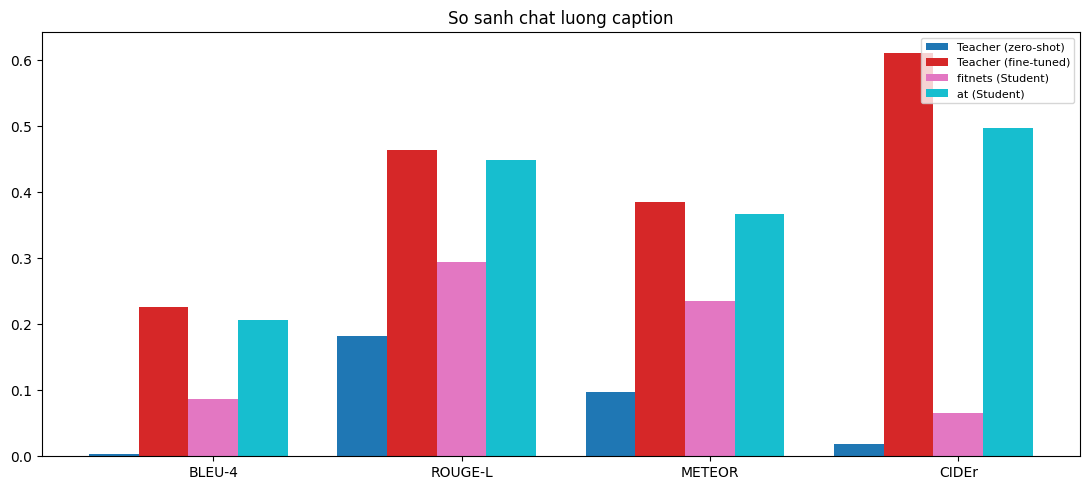

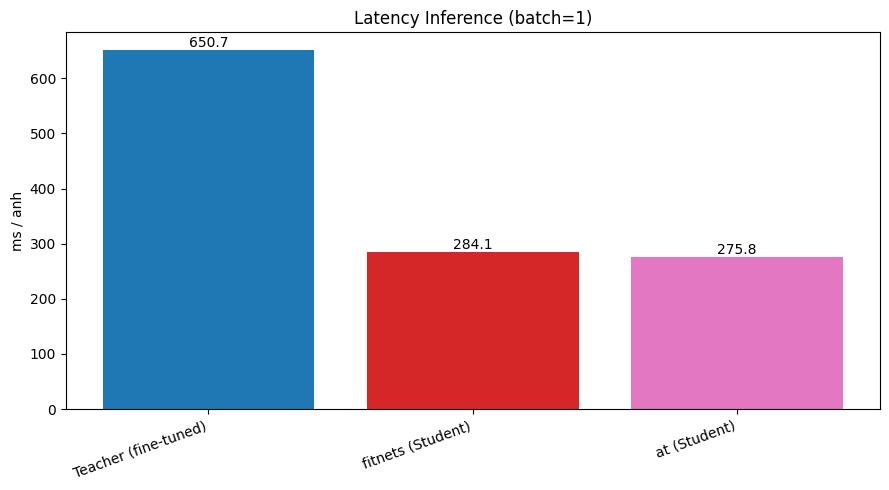

In [26]:
# --- Bieu do so sanh chat luong ---
metrics_to_plot = ["BLEU-4", "ROUGE-L", "METEOR", "CIDEr"]
plot_models = list(accuracy_results.keys())
colors = plt.cm.tab10(np.linspace(0, 1, len(plot_models)))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(metrics_to_plot))
width = 0.8 / len(plot_models)
for i, model_name in enumerate(plot_models):
    vals = [accuracy_results[model_name].get(m, 0) for m in metrics_to_plot]
    ax.bar(x + (i - len(plot_models) / 2) * width, vals, width, label=model_name, color=colors[i])
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot); ax.set_title("So sanh chat luong caption")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

# --- Bieu do so sanh latency ---
fig, ax = plt.subplots(figsize=(9, 5))
names = df_runtime["Model"].tolist()
lat = df_runtime["Latency batch=1 (ms)"].tolist()
ax.bar(names, lat, color=colors[: len(names)])
ax.set_ylabel("ms / anh"); ax.set_title("Latency Inference (batch=1)")
for i, v in enumerate(lat):
    ax.text(i, v, f"{v:.1f}", ha="center", va="bottom")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()


## 14. Đánh giá định tính: ảnh + caption gốc + Teacher + 4 Student

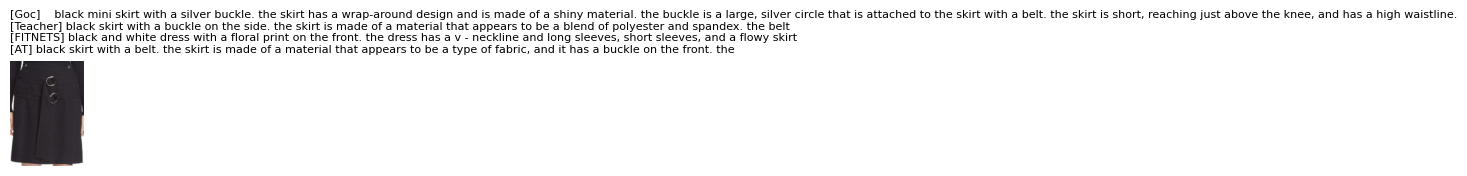

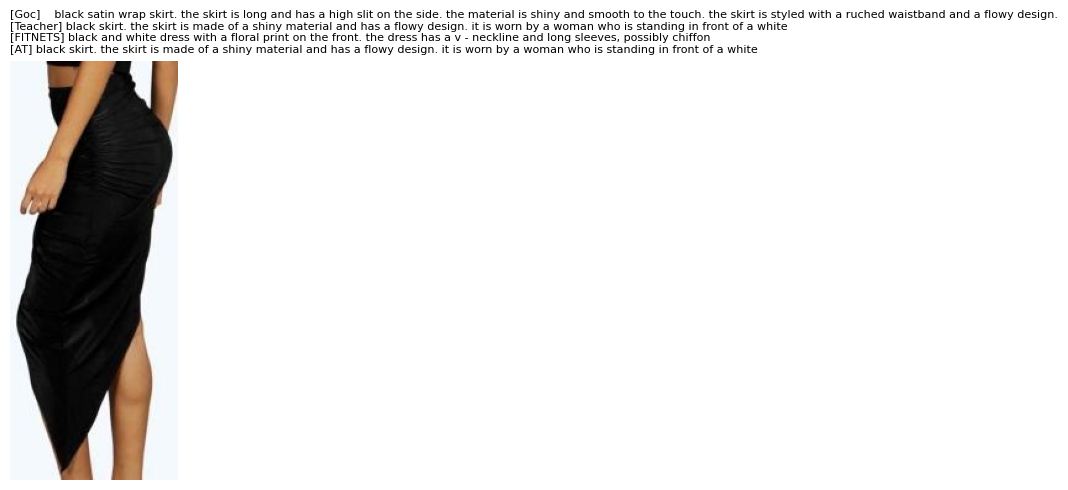

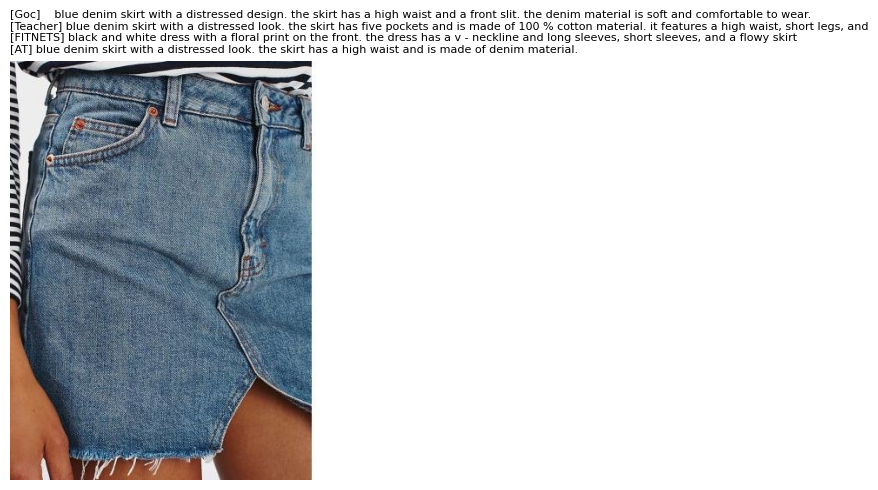

/tmp/ipykernel_58/4121102175.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


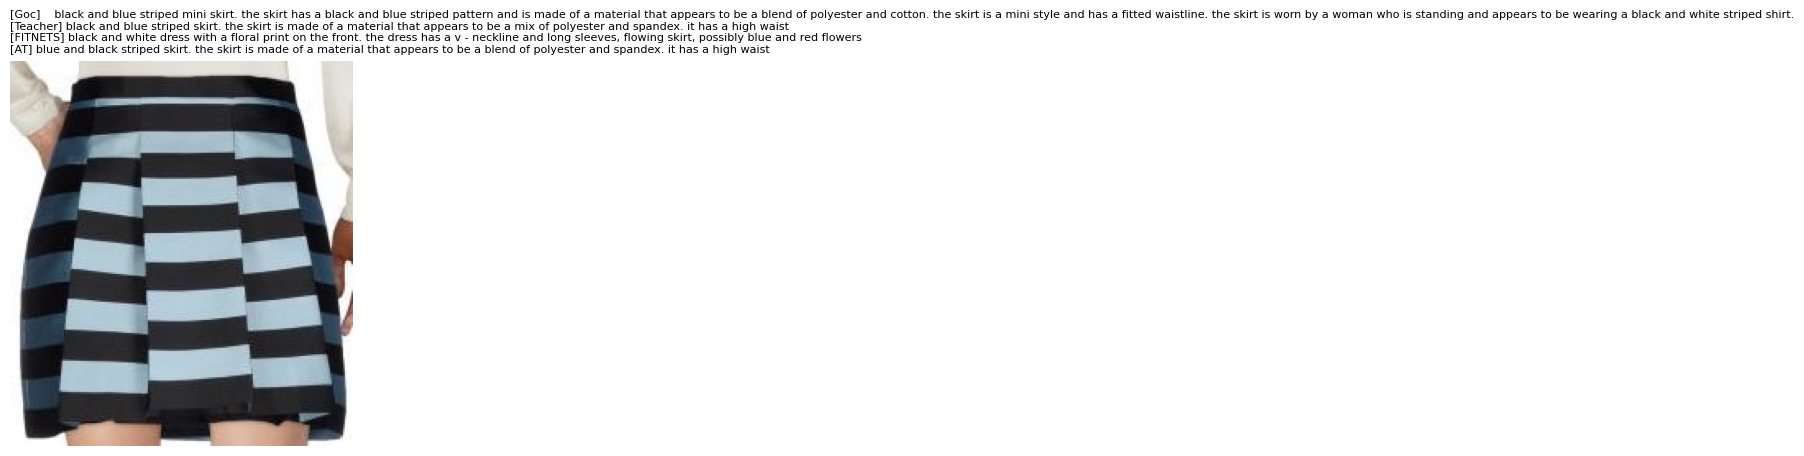

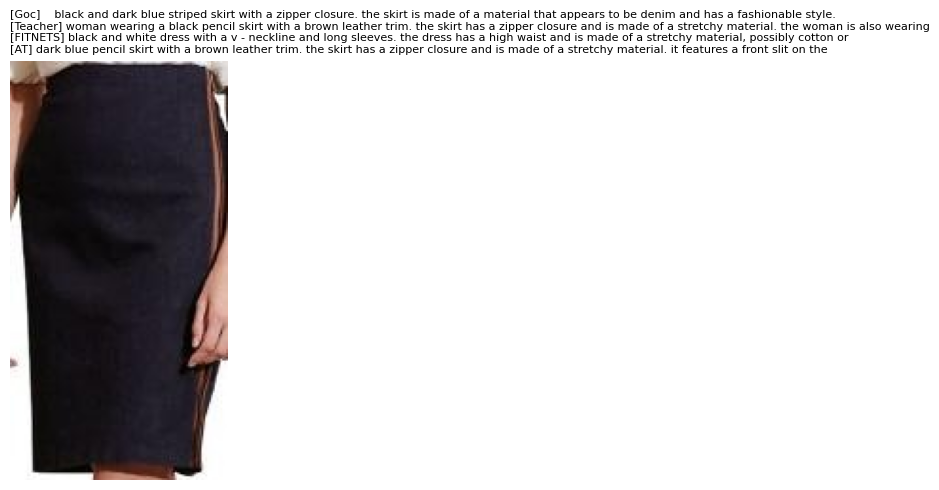

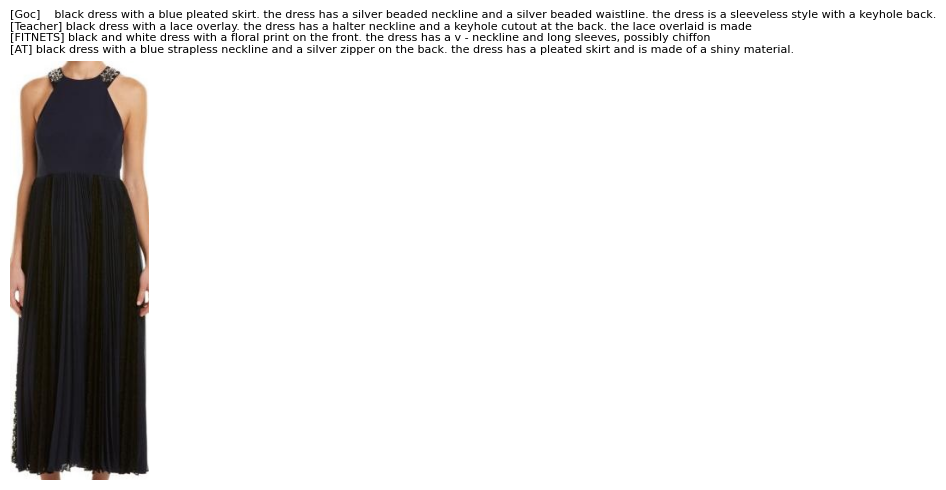

In [27]:
def show_qualitative_comparison(n_samples: int = 5, seed: int = RANDOM_SEED) -> None:
    """Hien thi n_samples anh test, kem caption goc / Teacher / tung Student."""
    rng = random.Random(seed)
    indices = rng.sample(range(len(fashion_test)), min(n_samples, len(fashion_test)))

    for idx in indices:
        item = fashion_test[idx]
        img = Image.open(item["image_path"]).convert("RGB")

        lines = [f"[Goc]    {item['caption']}"]

        t_inputs = SHARED_PROCESSOR(images=img, return_tensors="pt").to(DEVICE)
        t_inputs["pixel_values"] = t_inputs["pixel_values"].half()
        with torch.no_grad():
            t_ids = teacher_model.generate(**t_inputs, **gen_cfg.as_kwargs())
        lines.append(f"[Teacher] {SHARED_PROCESSOR.decode(t_ids[0], skip_special_tokens=True)}")

        for name, state in method_states.items():
            s_inputs = SHARED_PROCESSOR(images=img, return_tensors="pt").to(state.device)
            with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.float16, enabled=train_cfg.use_amp):
                s_ids = state.student.generate(**s_inputs, **gen_cfg.as_kwargs())
            cap = SHARED_PROCESSOR.decode(s_ids[0], skip_special_tokens=True)
            lines.append(f"[{name.upper()}] {cap}")

        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title("\n".join(lines), fontsize=8, loc="left")
        plt.tight_layout()
        plt.show()


show_qualitative_comparison(n_samples=6)


## 15. Lưu toàn bộ kết quả (để đối chiếu / viết thesis)

In [28]:
results_summary = {
    "accuracy": accuracy_results,
    "runtime": {k: {kk: vv for kk, vv in v.items() if kk != "throughput_by_batch"} for k, v in runtime_results.items()},
    "train_cost": train_cost_results,
    "arch_cfg": arch_cfg.__dict__,
    "train_cfg": train_cfg.__dict__,
    "gen_cfg": gen_cfg.__dict__,
    "methods_to_run": list(run_cfg.methods_to_run),
}
summary_path = os.path.join(run_cfg.output_root, "results_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(results_summary, f, ensure_ascii=False, indent=2, default=str)

logger.info(f"Da luu tong hop ket qua -> {summary_path}")
logger.info(f"Checkpoint Teacher -> {os.path.join(run_cfg.output_root, 'teacher_checkpoint.pth')}")
for name, path in best_ckpt_paths.items():
    logger.info(f"Checkpoint Student '{name}' -> {path}")


00:13:23 | INFO    | Da luu tong hop ket qua -> /kaggle/working/kd_compare_outputs/results_summary.json
00:13:23 | INFO    | Checkpoint Teacher -> /kaggle/working/kd_compare_outputs/teacher_checkpoint.pth
00:13:23 | INFO    | Checkpoint Student 'fitnets' -> /kaggle/working/kd_compare_outputs/best_student_fitnets.pth
00:13:23 | INFO    | Checkpoint Student 'at' -> /kaggle/working/kd_compare_outputs/best_student_at.pth


## 16. Chọn siêu tham số: thủ công hay Optuna?

**Khuyến nghị: chọn thủ công (manual), KHÔNG dùng Optuna cho lần chạy chính này.** Lý do cụ thể:

1. **Chi phí Optuna nhân với số lần train, không phải cộng.** Một trial Optuna nghĩa là chạy lại
   toàn bộ (hoặc phần lớn) vòng lặp train — với ~7.000 ảnh train × 4 phương pháp đã gần chạm ngưỡng
   6–8 tiếng chỉ với **1 lần chạy duy nhất mỗi phương pháp**; thêm dù chỉ 5–10 trial Optuna cho mỗi
   phương pháp sẽ khiến tổng thời gian vượt xa mọi ngân sách Kaggle hợp lý.
2. **Không gian tham số ở đây không "nhạy"** theo kiểu cần tự động dò: `temperature=4`,
   `λ_response=λ_feature=1` là các giá trị đã được dùng phổ biến trong literature KD (Hinton et al.
   cho T; nhiều paper distillation dùng trọng số bằng nhau làm baseline hợp lý) và **đã từng chạy ổn
   trên chính notebook Stage 1** của nhóm (theo bộ nhớ trò chuyện) — dùng lại là lựa chọn ít rủi ro
   nhất trong quỹ thời gian hạn hẹp.
3. **7.000 ảnh train là tập tương đối nhỏ.** Dò tham số tự động trên tập nhỏ dễ "quá khớp" vào chính
   tập validation (chọn ra bộ tham số tốt nhất *cho đúng 1.000 ảnh val này*), trong khi lợi ích thực
   tế (so với 1 bộ tham số hợp lý chọn thủ công) thường rất nhỏ ở quy mô dữ liệu này — không tương
   xứng với chi phí thời gian bỏ ra.
4. **Mục tiêu chính của thí nghiệm là SO SÁNH 4 phương pháp Feature-KD**, không phải tối ưu tuyệt đối
   từng phương pháp. Nếu dùng Optuna riêng cho từng phương pháp, sự khác biệt kết quả giữa 4 phương
   pháp sẽ lẫn cả yếu tố "phương pháp nào được search kỹ hơn" — làm nhiễu kết luận khoa học muốn rút
   ra (so sánh không còn "cân bằng" giữa 4 điều kiện).

**Nếu vẫn muốn tinh chỉnh nhẹ (tuỳ chọn, không bắt buộc):** chỉ nên chạy **1 study Optuna nhỏ, dùng
CHUNG cho cả 4 phương pháp** (không phải 4 study riêng) — ví dụ 4–6 trial, mỗi trial chỉ 1–2 epoch
trên một tập con nhỏ (~500–800 ảnh), chỉ dò `lr` và tỉ lệ `λ_feature/λ_response`, dùng
`optuna.pruners.HyperbandPruner` để dừng sớm trial kém. Kết quả (nếu có) áp dụng đồng loạt cho cả 4
phương pháp ở lần chạy full, để đảm bảo so sánh công bằng. Cell tham khảo (tắt mặc định) ở dưới.


In [ ]:
RUN_OPTIONAL_OPTUNA_SEARCH = False  # bat True neu muon thu (se ton them thoi gian dang ke)

if RUN_OPTIONAL_OPTUNA_SEARCH:
    import optuna

    def quick_objective(trial: "optuna.Trial") -> float:
        lr = trial.suggest_float("lr", 5e-6, 5e-5, log=True)
        feat_ratio = trial.suggest_float("lambda_feature_ratio", 0.5, 2.0)

        tmp_cfg = replace(train_cfg, lr=lr, lambda_feature=feat_ratio, num_epochs=1, batch_size=train_cfg.batch_size)
        tmp_state = build_method_state("fitnets", arch_cfg, tmp_cfg, TEACHER_VISION_HIDDEN, N_HINT_LAYERS)
        small_train = fashion_train[:600]
        small_val = fashion_val[:150]

        for batch in iter_batches(small_train, tmp_cfg.batch_size):
            run_one_batch(batch, teacher_model, teacher_hooks, {"fitnets": tmp_state}, SHARED_PROCESSOR, tmp_cfg, is_train=True)

        val_losses = []
        for batch in iter_batches(small_val, tmp_cfg.batch_size):
            losses = run_one_batch(batch, teacher_model, teacher_hooks, {"fitnets": tmp_state}, SHARED_PROCESSOR, tmp_cfg, is_train=False)
            val_losses.append(losses["fitnets"])

        tmp_state.hooks.remove()
        free_gpu(tmp_state.optimizer, tmp_state.scheduler, tmp_state.scaler, tmp_state.student, tmp_state.feature_module)
        return sum(val_losses) / max(len(val_losses), 1)

    study = optuna.create_study(direction="minimize", pruner=optuna.pruners.HyperbandPruner())
    study.optimize(quick_objective, n_trials=6)
    logger.info(f"Optuna best params (dung chung cho ca 4 phuong phap): {study.best_params}")
else:
    print("Bo qua Optuna (RUN_OPTIONAL_OPTUNA_SEARCH=False) — dung bo sieu tham so thu cong trong TrainConfig.")


In [29]:
from huggingface_hub import HfApi, create_repo

HF_USERNAME = "qa994"

HF_RESULTS_REPO = f"{HF_USERNAME}/blip-kd-results-fitnes-at-fashion200k"


def get_hf_token() -> str:
    """Lay HF token uu tien tu Kaggle Secrets, tranh hardcode token truc tiep trong code.

    Cach tao secret: vao Kaggle Notebook -> Add-ons -> Secrets -> them secret ten 'HF_TOKEN'
    voi gia tri la HuggingFace access token (chon quyen 'Write').
    """
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("HF_TOKEN2")
    except Exception as e:
        logger.warning(f"Khong lay duoc HF_TOKEN tu Kaggle Secrets ({e}), thu dung bien moi truong.")
        token = os.environ.get("HF_TOKEN2")
        if not token:
            raise RuntimeError(
                "Khong tim thay HF_TOKEN2. Them Kaggle Secret ten 'HF_TOKEN' (quyen Write) roi chay lai."
            ) from e
        return token


hf_token = get_hf_token()
api = HfApi(token=hf_token)

try:
    create_repo(repo_id=HF_RESULTS_REPO, repo_type="dataset", token=hf_token, exist_ok=True, private=False)
except Exception as e:
    logger.error(f"Khong tao/xac nhan duoc repo {HF_RESULTS_REPO}: {e}")
    raise

# Upload toan bo output_root (checkpoint mgd/spkd + results_summary.json), dat trong 1 thu muc con
# dat ten theo methods_to_run de khong de bi ghi de len ket qua cua Kaggle A khi 2 ben cung push chung 1 repo.
subfolder = f"kaggle_run_{'_'.join(run_cfg.methods_to_run)}"
logger.info(f"Dang upload {run_cfg.output_root} -> {HF_RESULTS_REPO}/{subfolder} ...")

api.upload_folder(
    folder_path=run_cfg.output_root,
    repo_id=HF_RESULTS_REPO,
    repo_type="dataset",
    path_in_repo=subfolder,
    commit_message=f"Ket qua Kaggle: {run_cfg.methods_to_run}",
)

logger.info(f"Da upload xong -> https://huggingface.co/datasets/{HF_RESULTS_REPO}/tree/main/{subfolder}")

00:13:23 | INFO    | HTTP Request: POST https://huggingface.co/api/repos/create "HTTP/1.1 200 OK"
00:13:23 | INFO    | Dang upload /kaggle/working/kd_compare_outputs -> qa994/blip-kd-results-fitnes-at-fashion200k/kaggle_run_fitnets_at ...
00:13:24 | INFO    | HTTP Request: POST https://huggingface.co/api/datasets/qa994/blip-kd-results-fitnes-at-fashion200k/preupload/main "HTTP/1.1 200 OK"
00:13:38 | INFO    | HTTP Request: POST https://huggingface.co/api/datasets/qa994/blip-kd-results-fitnes-at-fashion200k/commit/main "HTTP/1.1 200 OK"
00:13:38 | INFO    | Da upload xong -> https://huggingface.co/datasets/qa994/blip-kd-results-fitnes-at-fashion200k/tree/main/kaggle_run_fitnets_at
